In [1]:
# Cell # 1
# ============================================================
# Citi Bike Tableau Public Dataset Preparation
# ===========================================================
# Project Objective
# -----------------
#
# The purpose of this notebook is to transform an
# existing cleaned Citi Bike dataset into Tableau-
# ready datasets that support dashboard development,
# visualization, and business recommendations.
# List of Citi Bike 2025 ZIP file URLs (Winter 202502 + Sprig 202505 + Summer 202508)
# Source Dataset
# --------------
# Input File: citibike_clean.csv
#
# The source dataset was created in a separate
# notebook where the following tasks were completed:
#
# - Combined monthly Citi Bike trip data
# - Converted timestamps to datetime format
# - Calculated trip duration
# - Removed invalid ride records
# - Removed records with missing station information
# - Removed records with missing coordinates
# - Created derived calendar fields
#
# Project Workflow
# ----------------
# 1. Load the cleaned master dataset.
# 2. Validate the structure of the dataset.
# 3. Analyze seasonal distributions.
# 4. Create a representative 10% stratified sample.
# 5. Validate that the sample preserves ridership patterns.
# 6. Investigate station identifiers.
# 7. Determine whether station names or station IDs
#    should be used as the primary business dimension.
# 8. Create Tableau-ready datasets.
# 9. Export datasets for Tableau Public.
#
# Deliverables
# ------------
# citibike_tableau_clean.csv
#     Trip-level Tableau dataset
# citibike_station_activity.csv
#     Station popularity dataset
# ============================================================
# data source:
# https://s3.amazonaws.com/tripdata/index.html
# https://data.cityofnewyork.us/Transportation/Bicycle-Parking/592z-n7dk/about_data
# https://citibikenyc.com/system-data
# https://groups.google.com/g/citibike-hackers/about
# https://www.nyc.gov/html/dot/html/bicyclists/bikestats.shtml#counts
# https://www.nyc.gov/html/dot/html/about/datafeeds.shtml#Bikes
# https://github.com/MobilityData/gbfs/blob/master/gbfs.md

In [2]:
# ============================================================
# Cell # 2 Import Required Libraries
# Note: Data cleaning has already been completed in a
# separate notebook.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
# ============================================================
# Cell #3 Connect Google Drive
# Purpose:
# Access the master Citi Bike dataset stored in Google Drive.
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

#Define Dataset Paths

source_file = (
    '/content/drive/MyDrive/CitibikeDataSets/'
    'citibike_clean.csv'
)

print("Source Dataset:")
print(source_file)

Mounted at /content/drive
Source Dataset:
/content/drive/MyDrive/CitibikeDataSets/citibike_clean.csv


In [4]:
# ============================================================
# Cell #4 Verify Source Dataset
#
# Purpose:
# Confirm the source dataset exists and contains
# the expected structure before creating the
# Tableau version.
# ============================================================

df_check = pd.read_csv(
    source_file,
    nrows=5
)

print("Rows Preview:", len(df_check))
print("Columns:", len(df_check.columns))

print("\nColumn Names")
print("------------")
print(df_check.columns)

display(df_check.head())

Rows Preview: 5
Columns: 19

Column Names
------------
Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', 'duration_min', 'hour', 'day_of_week', 'month',
       'is_weekend', 'season'],
      dtype='object')


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,duration_min,hour,day_of_week,month,is_weekend,season
0,6AD8AA6957718325,classic_bike,2025-02-28 15:20:51.021,2025-02-28 15:25:52.490,Murray St & West St,5329.08,Liberty St & Nassau St,5105.09,40.715030,-74.012460,40.708589,-74.009355,member,5.024483,15,Friday,2,False,Winter
1,5BB04C2CEFA8A102,electric_bike,2025-02-17 10:10:37.715,2025-02-17 10:19:50.960,Park Ave & E 41 St,6432.08,St Marks Pl & 1 Ave,5626.13,40.751581,-73.977910,40.727791,-73.985649,member,9.220750,10,Monday,2,False,Winter
2,AFD4A963A22D88F8,classic_bike,2025-02-25 16:17:32.232,2025-02-25 16:21:53.863,Metropolitan Ave & Bedford Ave,5308.04,Metropolitan Ave & Meeker Ave,5300.05,40.715348,-73.960241,40.714133,-73.952344,member,4.360517,16,Tuesday,2,False,Winter
3,88D574957422333E,electric_bike,2025-02-28 18:03:33.721,2025-02-28 18:14:15.107,1 Ave & E 18 St,5854.09,5 Ave & E 30 St,6248.08,40.733812,-73.980544,40.745985,-73.986295,member,10.689767,18,Friday,2,False,Winter
4,0C5D956527417445,electric_bike,2025-02-23 18:14:37.859,2025-02-23 18:19:17.358,Park Ave & E 41 St,6432.08,5 Ave & E 30 St,6248.08,40.751581,-73.977910,40.745985,-73.986295,member,4.658317,18,Sunday,2,True,Winter


In [5]:
# ============================================================
# CELL 5  - Load Master Dataset
# ============================================================
# Purpose:
# Load the cleaned Citi Bike dataset into memory.
#
# The dataset will be reused throughout this notebook.
# Loading it once avoids repeated disk reads and makes
# the notebook easier to maintain.
# ============================================================

# df = pd.read_csv(source_file)
# the above expression line produce a warning : DtypeWarning: Columns (5,7)
# have mixed types, because Start_station_id and end_station_id
# columns have the following data format: 4001.09 which panda interprets it
# as float number but this should be an string.  changed the above line to
# the following: Read the whole file before deciding column types.

df = pd.read_csv(
    source_file,
    low_memory=False,
    dtype={
        'start_station_id': str,
        'end_station_id': str
    }
)

print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(11444071, 19)


In [6]:
# ============================================================
# CELL 6 Verify Dataset Structure and Data Completeness
# ============================================================
# Purpose:
#
# Review column data types and verify that all
# required fields were loaded successfully.
#
# Why?
#
# This validation confirms:
#
# - Expected data types
# - Dataset size
# - Non-null value counts
# - Coordinate completeness
#
# ============================================================

df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11444071 entries, 0 to 11444070
Data columns (total 19 columns):
 #   Column              Non-Null Count     Dtype  
---  ------              --------------     -----  
 0   ride_id             11444071 non-null  object 
 1   rideable_type       11444071 non-null  object 
 2   started_at          11444071 non-null  object 
 3   ended_at            11444071 non-null  object 
 4   start_station_name  11444071 non-null  object 
 5   start_station_id    11444071 non-null  object 
 6   end_station_name    11444071 non-null  object 
 7   end_station_id      11444071 non-null  object 
 8   start_lat           11444071 non-null  float64
 9   start_lng           11444071 non-null  float64
 10  end_lat             11444071 non-null  float64
 11  end_lng             11444071 non-null  float64
 12  member_casual       11444071 non-null  object 
 13  duration_min        11444071 non-null  float64
 14  hour                11444071 non-null  int64  
 

In [7]:
# ============================================================
# CELL 7 - Verify Seasonal Distribution
# ============================================================
# Purpose:
#
# Review the number of rides contained in each season
# within the full cleaned Citi Bike dataset.
#
# Why?
#
# Before creating a Tableau sample dataset, we need
# to understand the seasonal distribution of the
# original data.
#
# These counts will later be compared against the
# sampled dataset to verify that the sampling process
# preserved the original seasonal patterns.
#
# Expected Result:
#
# Summer should contain the most rides, followed by
# Spring and then Winter.
#
# ============================================================

season_counts = df['season'].value_counts()

print("Season Distribution")
print("-------------------")
print(season_counts)

Season Distribution
-------------------
season
Summer    5106781
Spring    4311340
Winter    2025950
Name: count, dtype: int64


In [8]:
# ============================================================
# CELL 8 - Calculate Seasonal Percentages
# ============================================================
# Purpose:
#
# Convert seasonal ride counts into percentages of
# the total dataset.
#
# Why?
#
# Percentages are easier to compare than raw ride
# counts because they show each season's share of
# overall ridership.
#
# These percentages will serve as a baseline for
# validating the 10% Tableau sample created later.
#
# Expected Result:
#
# The largest percentage should belong to Summer,
# followed by Spring and then Winter.
#
# ============================================================

season_percent = (
    season_counts / season_counts.sum()
) * 100

print("Season Percentage Distribution")
print("------------------------------")
print(season_percent.round(2))

Season Percentage Distribution
------------------------------
season
Summer    44.62
Spring    37.67
Winter    17.70
Name: count, dtype: float64


In [9]:
# ============================================================
# CELL 9 - Station Activity Analysis Consideration
# ============================================================
#
# Summary:
# Station popularity will be measured using:
#     Total Activity
#     = Departures + Arrivals
#
# This approach captures overall station usage
# and will be used for station rankings and maps
# in Tableau.
#
# ------------------------------------------------------------
# Detailed Explanation
# ------------------------------------------------------------
#
# Business Question:
#
# Which Citi Bike stations are the busiest?
#
# Important Consideration:
#
# A station may appear in the dataset as:
#
# 1. A trip origin (start station)
# 2. A trip destination (end station)
#
# Example:
#
# Rider 1 : Station A -> Station B
# Rider 2 : Station A -> Station B
# Rider 3 : Station B -> Station A
#
# Counting only departures would indicate that
# Station A is more active.
#
# Counting only arrivals would indicate that
# Station B is more active.
#
# Neither approach captures total station usage.
#
# Therefore:
#
# Total Activity =
# Number of Departures + Number of Arrivals
#
# Tableau Goal:
#
# Create a station activity map that identifies
# the most active Citi Bike stations regardless
# of whether trips start or end at those locations.
#
# Potential Metrics:
#
# - Departures
# - Arrivals
# - Total Activity
# - Percent of Total Station Activity
#
# ============================================================

In [10]:
# ============================================================
# CELL 10 - Verify Season Categories
# ============================================================
# Summary:
# Review the unique season values available in the
# dataset before creating seasonal samples.
#
# Detailed Explanation:
#
# The sampling process relies on the season field.
# Before creating Winter, Spring, and Summer
# samples, verify the exact season values stored
# in the dataset.
#
# Expected Result:
#
# Winter
# Spring
# Summer
#
# ============================================================

print("Season Categories")
print("-----------------")
print(df['season'].unique())

Season Categories
-----------------
['Winter' 'Spring' 'Summer']


In [11]:
# ============================================================
# CELL 11 - Create 10% Stratified Tableau Sample
# ============================================================
# Summary:
# Create a Tableau-friendly sample dataset that
# reduces file size while preserving the original
# seasonal distribution of rides.
#
# A 10% random sample is selected independently
# from Winter, Spring, and Summer, then combined
# into a single sample dataset.
#
# ------------------------------------------------------------
# Detailed Explanation
# ------------------------------------------------------------
#
# The master dataset contains:
#
# - 11,444,071 rides
# - 19 columns
# - Approximately 2.52 GB
#
# While suitable for analysis, the full dataset
# is larger than necessary for most Tableau Public
# dashboards.
#
# Sampling reduces file size and improves Tableau
# performance while maintaining representative
# seasonal ridership patterns.
#
# Sampling Method:
#
# Winter Sample  -> 10% of Winter rides
# Spring Sample  -> 10% of Spring rides
# Summer Sample  -> 10% of Summer rides
#
# Each seasonal sample is created independently
# to preserve the original seasonal distribution.
#
# The resulting seasonal samples are combined into
# a single Tableau preparation dataset.
#
# random_state = 42
#
# Ensures the same random sample is generated each
# time the notebook is executed, allowing results
# to be reproduced consistently.
#
# Expected Result:
#
# The sampled dataset should contain approximately
# 10% of the rides from each season while preserving
# the same seasonal proportions observed in the
# original dataset.
#
# ============================================================

# Select a 10% random sample from Winter rides
# ------------------------------------------------------------
winter_sample = (
    df[df['season'] == 'Winter']
    .sample(
        frac=0.10,
        random_state=42
    )
)

# ------------------------------------------------------------
# Select a 10% random sample from Spring rides
# ------------------------------------------------------------
spring_sample = (
    df[df['season'] == 'Spring']
    .sample(
        frac=0.10,
        random_state=42
    )
)

# ------------------------------------------------------------
# Select a 10% random sample from Summer rides
# ------------------------------------------------------------
summer_sample = (
    df[df['season'] == 'Summer']
    .sample(
        frac=0.10,
        random_state=42
    )
)

# ------------------------------------------------------------
# Combine all seasonal samples into a single DataFrame
# ------------------------------------------------------------
df_sample = pd.concat([
    winter_sample,
    spring_sample,
    summer_sample
])

# ------------------------------------------------------------
# Display the size of the Tableau sample dataset
# ------------------------------------------------------------
print("Tableau Sample Shape")
print("--------------------")
print(df_sample.shape)

# Reset index
df_sample = df_sample.reset_index(drop=True)

Tableau Sample Shape
--------------------
(1144407, 19)


In [12]:
print(df_sample.dtypes)

ride_id                object
rideable_type          object
started_at             object
ended_at               object
start_station_name     object
start_station_id       object
end_station_name       object
end_station_id         object
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual          object
duration_min          float64
hour                    int64
day_of_week            object
month                   int64
is_weekend               bool
season                 object
dtype: object


In [13]:
# ============================================================
# CELL 12 Validate Stratified Sample
# ============================================================
#
# Summary:
#
# Verify that the 10% stratified sample preserves
# the original seasonal distribution of the full
# Citi Bike dataset.
#
# ------------------------------------------------------------
# Detailed Explanation
# ------------------------------------------------------------
#
# After creating the Winter, Spring, and Summer
# samples, validation is required to confirm that
# the sampling process worked as intended.
#
# Validation Objectives:
#
# 1. Confirm that approximately 10% of rides were
#    selected from each season.
#
# 2. Confirm that the seasonal percentages in the
#    sample remain close to the percentages found
#    in the original dataset.
#
# Why?
#
# If the sample preserves the original seasonal
# distribution, analyses and visualizations created
# in Tableau should remain representative of the
# full dataset while requiring significantly less
# storage and processing resources.
#
# Expected Result:
#
# - Winter sample ≈ 10% of Winter rides
# - Spring sample ≈ 10% of Spring rides
# - Summer sample ≈ 10% of Summer rides
#
# The seasonal percentages should closely match the
# percentages calculated previously in Cell 8.
#
# ============================================================

In [14]:
# ============================================================
# CELL 13 - Verify Seasonal Sample DataFrames
# ============================================================
#
# Purpose:
# Verify that each seasonal sample was created
# successfully and review the number of rows
# selected from each season.
# ============================================================
print("Winter Sample Shape:")
print(winter_sample.shape)

print("\nSpring Sample Shape:")
print(spring_sample.shape)

print("\nSummer Sample Shape:")
print(summer_sample.shape)

Winter Sample Shape:
(202595, 19)

Spring Sample Shape:
(431134, 19)

Summer Sample Shape:
(510678, 19)


In [15]:
# ============================================================
# CELL 14 - Preview Seasonal Sample Records
# ============================================================
# Summary:
# Display sample records from each seasonal DataFrame
# to verify that the sampled data appears correct.
#
# ------------------------------------------------------------
# Detailed Explanation
# ------------------------------------------------------------
#
# The previous cell verified the structure of each
# seasonal sample using the DataFrame shape.
#
# This cell performs a visual inspection of the data
# by displaying the first few records from:
#
# - winter_sample
# - spring_sample
# - summer_sample
#
# Reviewing sample records helps confirm that:
#
# - The expected columns are present.
# - Data values appear reasonable.
# - The sampling process produced valid records.
#
# ============================================================

display(winter_sample.head())
display(spring_sample.head())
display(summer_sample.head())

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,duration_min,hour,day_of_week,month,is_weekend,season
387670,8A966AD0F8380C5F,electric_bike,2025-02-22 15:36:39.651,2025-02-22 15:50:32.116,St Johns Pl & Washington Ave,4001.09,S 2 St & Kent Ave,5276.04,40.673724,-73.963161,40.714731,-73.966612,member,13.874417,15,Saturday,2,True,Winter
1692352,AC520E1B6FF6ACE0,electric_bike,2025-02-11 11:21:12.077,2025-02-11 11:28:28.835,Atlantic Ave & Furman St,4614.04,Front St & Jay St,4895.03,40.691652,-73.999979,40.702461,-73.986842,member,7.279300,11,Tuesday,2,False,Winter
1982633,A873EA0B0A13F444,electric_bike,2025-02-05 12:35:51.970,2025-02-05 12:41:48.080,W 47 St & 9 Ave,6786.02,11 Ave & W 59 St,7059.01,40.761530,-73.990070,40.771497,-73.990460,member,5.935167,12,Wednesday,2,False,Winter
1912288,D776862F04679758,electric_bike,2025-02-09 12:03:55.860,2025-02-09 12:20:19.054,East End Ave & E 86 St,7113.08,Columbus Ave & W 95 St,7520.07,40.775186,-73.944461,40.791956,-73.968087,member,16.386567,12,Sunday,2,True,Winter
11047,058477235E5C13A3,electric_bike,2025-02-19 13:31:33.802,2025-02-19 13:33:56.746,Bradhurst Ave & W 148 St,7992.04,W 155 St & Frederick Douglass Blvd,8065.13,40.825125,-73.941616,40.829230,-73.936996,member,2.382400,13,Wednesday,2,False,Winter


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,duration_min,hour,day_of_week,month,is_weekend,season
6209037,04FC5F9EAFE8EE7F,electric_bike,2025-05-18 16:26:08.008,2025-05-18 16:30:23.571,E 11 St & 1 Ave,5746.14,University Pl & E 14 St,5905.14,40.729538,-73.984267,40.734814,-73.992085,member,4.259383,16,Sunday,5,True,Spring
2137572,F3081AE0432949BC,electric_bike,2025-05-24 14:16:06.334,2025-05-24 14:30:17.646,W 34 St & 11 Ave,6578.01,West St & Chambers St,5329.03,40.755942,-74.002116,40.717548,-74.013221,member,14.188533,14,Saturday,5,True,Spring
4206979,8226CB538FCA4799,electric_bike,2025-05-10 11:19:22.243,2025-05-10 11:59:47.689,Sterling Pl & Classon Ave,4033.18,Commerce St & Van Brunt St,4243.01,40.673941,-73.960260,40.681212,-74.008609,member,40.424100,11,Saturday,5,True,Spring
2416050,8FCE644EBE5F9AD3,electric_bike,2025-05-31 12:59:48.024,2025-05-31 13:02:45.651,6 Ave & 9 St,3803.09,Prospect Park West & 8 St,3722.04,40.668127,-73.983776,40.665147,-73.976376,member,2.960450,12,Saturday,5,True,Spring
3586455,8723DB2A0855B764,classic_bike,2025-05-10 14:31:55.783,2025-05-10 14:42:29.110,3 Ave & E 72 St,7028.04,E 74 St & 1 Ave,6953.08,40.769943,-73.960607,40.768974,-73.954823,member,10.555450,14,Saturday,5,True,Spring


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,duration_min,hour,day_of_week,month,is_weekend,season
6980743,8DF4B26E3B91DA76,electric_bike,2025-08-30 11:32:15.192,2025-08-30 11:40:11.949,W 147 St & Adam Clayton Powell Blvd,7971.07,Madison Ave & E 120 St,7667.04,40.822810,-73.937413,40.802950,-73.942954,member,7.945950,11,Saturday,8,True,Summer
11183816,347ED3DAF4A3C066,electric_bike,2025-08-18 17:09:41.530,2025-08-18 18:13:55.437,Ashland Pl & Dekalb Ave,4513.09,5 Ave & E 135 St,7769.06,40.690065,-73.978776,40.812191,-73.937838,casual,64.231783,17,Monday,8,False,Summer
10523125,4DD11DECE5D6953F,classic_bike,2025-08-09 09:45:55.422,2025-08-09 10:27:56.392,Lafayette St & Jersey St,5561.06,3 Ave & Schermerhorn St,4437.01,40.724561,-73.995653,40.686832,-73.979677,member,42.016167,9,Saturday,8,True,Summer
8299001,4C1DB453538EAB1E,electric_bike,2025-08-17 16:06:19.644,2025-08-17 16:14:59.768,E 17 St & Broadway,5980.10,8 Ave & W 24 St,6224.06,40.737006,-73.990134,40.745911,-73.998071,member,8.668733,16,Sunday,8,True,Summer
6568520,AD710AB2F03CBCC0,classic_bike,2025-08-26 19:31:50.381,2025-08-26 19:34:40.321,1 Ave & E 18 St,5854.09,E 17 St & 2 Ave,5896.01,40.733812,-73.980544,40.734312,-73.983725,member,2.832333,19,Tuesday,8,False,Summer


In [16]:
# ============================================================
# CELL 15 - Trip Duration Investigation
# ============================================================
# Summary:
# Compare trip duration statistics between Member
# and Casual riders.
# This analysis helps identify differences in rider
# behavior and may support future Tableau dashboards
# and business recommendations.
# ------------------------------------------------------------
# Detailed Explanation
# ------------------------------------------------------------
#
# Trip duration is calculated in minutes and is
# summarized separately for each rider type.
#
# Metrics Calculated:
#
# - Count   : Number of trips
# - Mean    : Average trip duration
# - Median  : Middle trip duration value
#
# Metrics Calculated
# - Count : Number of trips.
# - Mean : Average trip duration across all trips.
# - Median : Middle trip duration when all trips are
# ordered from shortest to longest.
# Why Both?
# The mean provides the overall average duration,
# while the median is less affected by unusually
# long or short trips and may better represent a
# typical ride.
#
# Comparing duration patterns between Member and
# Casual riders may reveal differences in how the
# Citi Bike system is being used.
#
# Examples:
#
# - Members may use Citi Bike primarily for
#   transportation and commuting.
#
# - Casual riders may use Citi Bike more often
#   for leisure, recreation, or occasional trips.
#
# Expected Result:
#
# Duration statistics will be displayed for both
# rider groups and used later to support Tableau
# visualizations and recommendations.
#
# ============================================================

duration_summary = (
    df_sample
    .groupby('member_casual')['duration_min']
    .agg(['count', 'mean', 'median'])
)

display(duration_summary)

,count,mean,median
member_casual,,,
casual,216735,19.653629,13.407233
member,927672,11.287855,8.320858


In [17]:
# ============================================================
# CELL 16 - Trip Duration Findings
# ============================================================
# Summary:
#
# Trip durations were compared between Member and
# Casual riders to identify potential differences
# in rider behavior.
#
# ------------------------------------------------------------
# Detailed Explanation
# ------------------------------------------------------------
# The duration statistics generated in Cell 14
# provide a foundation for understanding rider
# behavior within the Citi Bike system.
#
# Trip counts, average duration, and median
# duration were calculated for each rider type.
#
# These metrics help identify whether Members and
# Casual riders exhibit different usage patterns.
#
# The findings may support:
#
# - Rider behavior analysis
# - Member versus Casual dashboards
# - Trip duration dashboards
# - Business recommendations
#
# ============================================================

In [18]:
# ============================================================
# CELL 17 - Explore Station Identifier Structure
# ============================================================
# Summary:
# Compare the number of unique station IDs and
# station names in the sampled dataset.
# ------------------------------------------------------------
# Detailed Explanation
# ------------------------------------------------------------
# Station activity can be analyzed using either:
#
# - Station IDs
# - Station Names
#
# Before selecting a business dimension, investigate
# whether the number of unique station IDs differs
# from the number of unique station names.
#
# A significant difference may indicate that
# multiple station IDs are associated with the same
# station name.
#
# Expected Result:
#
# If more unique station IDs exist than station
# names, additional investigation will be required
# to understand the relationship between the two.
#
# ============================================================

print("Unique Start Station IDs:")
print(df_sample['start_station_id'].nunique())

print("\nUnique Start Station Names:")
print(df_sample['start_station_name'].nunique())


Unique Start Station IDs:
2268

Unique Start Station Names:
2171


In [19]:
# ============================================================
# CELL 18 - Investigation Direction
# ============================================================
#
# Summary:
#
# Investigate whether the decimal portion of a
# station ID represents a substation, docking area,
# or another variation of the same station.
#
# ------------------------------------------------------------
# Detailed Explanation
# ------------------------------------------------------------
#
# Station IDs contain values such as:
#
#     6140.05
#     6140.06
#     6140.07
#
# These values suggest that a station may have
# multiple related identifiers.
#
# This raises an important question:
#
# Do the digits after the decimal represent
# substations, docking areas, or unique station
# locations?
#
# Investigation Approach:
#
# Create a Master Station ID by removing the
# decimal suffix and compare the resulting
# station groupings.
#
# The results will help determine whether station
# activity should be analyzed using:
#
#     Station IDs
#
# or
#
#     Station Names
#
# ============================================================

In [20]:
# ============================================================
# CELL 19 - Create Master Station IDs
# ============================================================
#
# Summary:
#
# Create simplified station identifiers by removing
# the decimal suffix from station IDs.
#
# ------------------------------------------------------------
# Detailed Explanation
# ------------------------------------------------------------
#
# Station IDs contain values such as:
#
#     4101.09
#     4101.10
#     4101.15
#
# This cell creates a Master Station ID by keeping
# only the portion before the decimal point.
#
# Examples:
#
#     4101.09 -> 4101
#     4101.10 -> 4101
#     4101.15 -> 4101
#
# Why?
#
# This transformation allows us to investigate
# whether the digits after the decimal represent
# substations, docking areas, or variations of the
# same physical station.
#
# Expected Result:
#
# New fields will be created:
#
# - start_station_master_id
# - end_station_master_id
#
# These fields will be used in the next step of
# the station identifier investigation.
#
# ============================================================

df_sample['start_station_master_id'] = (
    df_sample['start_station_id']
    .str.split('.')
    .str[0]
)

df_sample['end_station_master_id'] = (
    df_sample['end_station_id']
    .str.split('.')
    .str[0]
)

print("Master Station IDs Created")

Master Station IDs Created


In [21]:
# ============================================================
# Cell 20 - Investigate Master Station ID Groupings
# ============================================================
#
# Purpose:
#
# Determine whether multiple station names become
# associated with the same Master Station ID after
# removing the decimal suffix.
#
# Why?
#
# If multiple station names share the same Master
# Station ID, then removing the decimal portion of
# the station identifier may hide important station
# differences.
#
# This investigation helps determine whether station
# activity should be analyzed using:
#
#     Master Station IDs
#
# or
#
#     Station Names
#
# Interpretation:
#
# Values greater than 1 indicate that multiple
# station names are associated with the same
# Master Station ID.
#
# ============================================================

master_id_names = (
    df_sample.groupby('start_station_master_id')
    ['start_station_name']
    .nunique()
    .sort_values(ascending=False)
)

print("Master Station IDs Associated With Multiple Names")
print("------------------------------------------------")

display(
    master_id_names[
        master_id_names > 1
    ].head(20)
)

Master Station IDs Associated With Multiple Names
------------------------------------------------


,start_station_name
start_station_master_id,
6432,4
5359,4
5626,4
5779,4
5788,4
6659,4
5847,4
6319,4
7286,3


In [22]:
# ============================================================
# Cell 21 - Master Station ID Investigation Conclusion
# ============================================================
# Station names will be used as the primary station
# dimension for Tableau analysis.
#
# Investigation of station IDs showed that removing
# the decimal suffix can associate multiple station
# names with the same master station ID.
#
# Until the Citi Bike data dictionary confirms the
# meaning of the station ID structure, station names
# will be treated as distinct stations.

In [23]:
# ============================================================
# Cell # 22
# Compare Start Station Names vs End Station Names
# ============================================================
#
# Purpose:
# Determine whether any station names appear only as
# start stations or only as end stations within the
# sampled dataset.
#
# Method:
# 1. Create a set of unique start station names.
# 2. Create a set of unique end station names.
# 3. Use set subtraction to identify names that
#    appear in one set but not the other.
#
# Interpretation:
# - only_in_start contains station names that
#   appear as trip origins but never as destinations.
#
# - only_in_end contains station names that
#   appear as trip destinations but never as origins.
# ============================================================

start_names = set(
    df_sample['start_station_name'].dropna()
)

end_names = set(
    df_sample['end_station_name'].dropna()
)

only_in_start = start_names - end_names

only_in_end = end_names - start_names

print(f'Only in Start Names: {len(only_in_start)}')
print(f'Only in End Names: {len(only_in_end)}')

Only in Start Names: 0
Only in End Names: 25


In [24]:
# ============================================================
# Cell 23 - Station Name versus Station ID Investigation
# ============================================================
#
# Purpose:
#
# Continue the station identifier investigation by
# examining the relationship between station names
# and station IDs.
#
# Why?
#
# If a station name is associated with multiple
# station IDs, then station activity may be split
# across several technical identifiers.
#
# This analysis will help determine whether Tableau
# dashboards should use:
#
#     Station Names
#
# or
#
#     Station IDs
#
# as the primary business dimension.
#
# ============================================================

In [25]:
# ============================================================
# Cell # 24
# Check if any station name maps to multiple IDs
# Purpose:
#
# Determine whether a station name can be associated
# with multiple station IDs.
#
# Multiple IDs per station name may indicate that
# the station name represents a broader business
# concept than the technical station identifier.
# ============================================================

name_to_ids = (
    df_sample.groupby('start_station_name')
    ['start_station_id']
    .nunique()
)

print(
    f"Names with more than one ID: "
    f"{(name_to_ids > 1).sum()}"
)

Names with more than one ID: 97


In [26]:
# ============================================================
# Cell 25 - Review Example Stations
# ============================================================
#
# Purpose:
#
# Examine specific examples of station names that
# are associated with multiple station IDs.
#
# Why?
#
# The previous cell quantified the number of
# affected stations.
#
# Reviewing actual examples helps determine
# whether multiple station IDs appear to represent
# the same business-facing station.
#
# ============================================================

In [27]:
# ============================================================
# Cell # 26
# ============================================================
# Station Names Associated With Multiple IDs
# Purpose:
#
# Display examples of station names associated with
# multiple station IDs.
#
# Provides evidence supporting the station-name
# investigation.
# ============================================================

multi_id_names = (
    df_sample.groupby('start_station_name')
    ['start_station_id']
    .nunique()
)

multi_id_names = multi_id_names[
    multi_id_names > 1
]

print(multi_id_names.head(5))

start_station_name
2 Ave & E 99 St         2
24 Ave & 26 St          2
3 Ave & E 82 St         2
3 St & Hoyt St          2
31 Ave & Crescent St    2
Name: start_station_id, dtype: int64


In [28]:
# ============================================================
# Cell # 27
# ============================================================
# Purpose:
#
# Determine whether a station ID can be associated
# with more than one station name.
#
# This validates whether station IDs uniquely
# identify station names.
# IDs Mapping To Multiple Names
# ============================================================

id_to_names = (
    df_sample.groupby('start_station_id')
    ['start_station_name']
    .nunique()
)

print(
    f"IDs with more than one Name: "
    f"{(id_to_names > 1).sum()}"
)

IDs with more than one Name: 0


In [29]:
# ============================================================
# Cell # 28
# ============================================================
# Results Interpretation
# ============================================================
#
# Findings:
#
# - 97 station names are associated with multiple
#   station IDs.
#
# - No station ID is associated with multiple
#   station names.
#
# Business Interpretation:
#
# The station ID appears to be a more granular
# technical identifier than the station name.
#
# Multiple technical station IDs may map to a
# single user-facing station name.
#
# However, each station ID maps to only one
# station name.
#
# Conclusion:
#
# Station names will be used as the primary
# business dimension because they represent the
# station concept most familiar to users.
#
# Station IDs will be retained in the dataset
# for auditing, validation, and traceability.
#
# ============================================================

In [30]:
# ============================================================
# Cell # 29 Busiest Stations Using Station Names
# ============================================================
#
# Purpose:
# Calculate total station activity using station names.
# Why?
#
# This ranking will be compared against the
# station-ID ranking to determine whether both
# methods produce similar business conclusions.

# Total Activity =
# Departures + Arrivals
#
# Station names are used as the grouping key.
#
# An example station ID is included only as a reference
# to help compare results with the station ID method.
# ============================================================

# Departures
start_name = (
    df_sample.groupby('start_station_name')
    .agg(
        station_id=('start_station_id', 'first'),
        departures=('start_station_name', 'size')
    )
)

# Arrivals
end_name = (
    df_sample.groupby('end_station_name')
    .agg(
        arrivals=('end_station_name', 'size')
    )
)

# Combine departures and arrivals
station_activity_name = (
    start_name
    .join(end_name, how='outer')
    .fillna(0)
)

# Total activity
station_activity_name['total_activity'] = (
    station_activity_name['departures']
    + station_activity_name['arrivals']
)

# Sort busiest stations first
station_activity_name = (
    station_activity_name
    .sort_values(
        'total_activity',
        ascending=False
    )
)

print("Top 20 Stations Using Station Names")

display(
    station_activity_name[
        ['station_id', 'departures', 'arrivals', 'total_activity']
    ]
    .head(20)
)

Top 20 Stations Using Station Names


,station_id,departures,arrivals,total_activity
W 21 St & 6 Ave,6140.05,4007.0,3987,7994.0
Pier 61 at Chelsea Piers,6233.04,3930.0,4022,7952.0
Lafayette St & E 8 St,5788.13,3667.0,3589,7256.0
West St & Chambers St,5329.03,3642.0,3603,7245.0
W 31 St & 7 Ave,6331.01,3251.0,3288,6539.0
9 Ave & W 33 St,6492.08,3289.0,3199,6488.0
Broadway & E 14 St,5905.12,3222.0,3235,6457.0
7 Ave & Central Park South,6912.01,3205.0,3199,6404.0
University Pl & E 14 St,5905.14,3173.0,3201,6374.0
11 Ave & W 41 St,6726.01,3128.0,3225,6353.0


In [31]:
# ============================================================
# Cell # 30
# ============================================================
# Busiest Stations Using Station IDs
# ============================================================
#
# Purpose:
# Calculate total station activity using station IDs.
#
# This ranking will be compared against the
# station-name ranking to validate the choice
# of station name as the Tableau business
# dimension

# Total Activity =
# Departures + Arrivals
#
# Station IDs are used as the grouping key.
#
# Station names are displayed to allow comparison
# with the station-name method.
# ============================================================

# Departures
start_id = (
    df_sample.groupby('start_station_id')
    .agg(
        station_name=('start_station_name', 'first'),
        departures=('start_station_id', 'size')
    )
)

# Arrivals
end_id = (
    df_sample.groupby('end_station_id')
    .agg(
        arrivals=('end_station_id', 'size')
    )
)

# Combine departures and arrivals
station_activity_id = (
    start_id
    .join(end_id, how='outer')
    .fillna(0)
)

# Total activity
station_activity_id['total_activity'] = (
    station_activity_id['departures']
    + station_activity_id['arrivals']
)

# Sort busiest stations first
station_activity_id = (
    station_activity_id
    .sort_values(
        'total_activity',
        ascending=False
    )
)

print("Top 20 Stations Using Station IDs")

display(
    station_activity_id[
        ['station_name', 'departures', 'arrivals', 'total_activity']
    ]
    .head(20)
)

Top 20 Stations Using Station IDs


,station_name,departures,arrivals,total_activity
6140.05,W 21 St & 6 Ave,4007.0,3987.0,7994.0
6233.04,Pier 61 at Chelsea Piers,3930.0,4022.0,7952.0
5788.13,Lafayette St & E 8 St,3667.0,3589.0,7256.0
5329.03,West St & Chambers St,3642.0,3603.0,7245.0
6331.01,W 31 St & 7 Ave,3251.0,3288.0,6539.0
6492.08,9 Ave & W 33 St,3289.0,3199.0,6488.0
5905.12,Broadway & E 14 St,3222.0,3235.0,6457.0
6912.01,7 Ave & Central Park South,3205.0,3199.0,6404.0
5905.14,University Pl & E 14 St,3173.0,3201.0,6374.0
6726.01,11 Ave & W 41 St,3128.0,3225.0,6353.0


In [32]:
# ============================================================
# Cell # 31 Station Name vs Station ID Validation
# ============================================================
# Purpose:
#
# Determine whether station activity analysis should
# use station names or station IDs as the primary
# grouping dimension.
#
# Method:
#
# 1. Calculate total station activity using station
#    names (Departures + Arrivals).
#
# 2. Calculate total station activity using station
#    IDs (Departures + Arrivals).
#
# 3. Compare the busiest stations produced by each
#    approach.
#
# Findings:
#
# - The busiest stations identified using station
#   names and station IDs were nearly identical.
#
# - The same stations appeared at the top of both
#   rankings with very similar activity totals.
#
# - Although some station names are associated with
#   multiple station IDs, this had little effect on
#   the overall station activity rankings.
#
# Conclusion:
#
# Station names were selected as the primary
# business dimension for Tableau visualizations.
#
# Station names are easier for end users to
# understand and produced the same business
# insights as station IDs for the busiest station
# analysis.
#
# Station IDs will be retained for validation,
# auditing, and troubleshooting purposes.
#
# ============================================================

In [33]:
# ============================================================
# Cell # 32  Tableau Data Model Decision
# ============================================================
#
# Two datasets will be exported for Tableau:
#
# Dataset 1
#
# citibike_tableau_clean.csv
#
# One Row = One Trip
#
# Used for:
#
# - Trends
# - Duration Analysis
# - Member vs Casual Analysis
# - Seasonal Analysis
# - Geographic Analysis
#
# Dataset 2
#
# citibike_station_activity.csv
#
# One Row = One Station
#
# Used for:
#
# - Top Stations
# - Station Popularity
# - Station Ranking
# - Station Activity Maps
#
# ============================================================

In [34]:
# ============================================================
# Cell 33 - Create Tableau Trip Dataset
# ========================================================================================================================
#
# Purpose:
#
# Create the primary Tableau dataset used for:
#
# - Temporal analysis
# - Seasonal analysis
# - Ride duration analysis
# - Member vs Casual analysis
# - Bike type analysis
# - Start station maps
# - End station maps
#
# Business Rule:
#
# Station names will be used as the primary
# business dimension.
#
# Station IDs will be retained for validation
# and troubleshooting purposes.
#
# Additional Fields:
#
# trip_date
# year_month
#
# These fields simplify filtering and time analysis
# inside Tableau.
#
# ============================================================
# ------------------------------------------------------------
# Cell 33.1
# Create a working copy of the sampled dataset.
# This preserves df_sample while allowing Tableau-
# specific modifications to be performed safely.
# ------------------------------------------------------------
df_tableau = df_sample.copy()
# ------------------------------------------------------------
# Cell 33.2
#
# Create a date-only field derived from started_at.
# This simplifies daily filtering and trend analysis
# within Tableau dashboards.
# ------------------------------------------------------------

df_tableau['trip_date'] = (
    pd.to_datetime(df_tableau['started_at'])
    .dt.date
)
# ------------------------------------------------------------
# Cell 33.3
#
# Create a Year-Month field from started_at.
# This field supports monthly trend analysis and
# simplifies filtering and grouping rides by month
# within Tableau.
# ------------------------------------------------------------

df_tableau['year_month'] = (
    pd.to_datetime(df_tableau['started_at'])
    .dt.strftime('%Y-%m')
)


# ------------------------------------------------------------
# Cell 33.4
#
# Define the columns that will be retained in the
# final Tableau trip-level dataset.
# Fields not required for the planned dashboards
# are excluded to reduce dataset size and simplify
# analysis within Tableau.
# ------------------------------------------------------------

tableau_columns = [

    'started_at',
    'ended_at',

    'trip_date',
    'year_month',

    'duration_min',

    'month',
    'season',
    'day_of_week',
    'hour',
    'is_weekend',

    'member_casual',
    'rideable_type',

    'start_station_id',
    'start_station_name',
    'start_lat',
    'start_lng',

    'end_station_id',
    'end_station_name',
    'end_lat',
    'end_lng'
]

# ------------------------------------------------------------
# Cell 33.5
#
# Create the final Tableau dataset by keeping only
# the analytical fields selected for dashboard
# development and visualization.
# ------------------------------------------------------------

df_tableau = df_tableau[tableau_columns]

# Confirm that the expected number of analytical
# fields were retained in the Tableau dataset.

print("Columns Retained:")
print(len(df_tableau.columns))

print("\nColumn Names:")
print(df_tableau.columns.tolist())

# ------------------------------------------------------------
# Cell 33.6
#
# Verify the structure of the new Tableau dataset and
# display sample records to confirm the dataset
# was created successfully.

# ------------------------------------------------------------

print("Tableau Trip Dataset Shape")
print("--------------------------")
print(df_tableau.shape)

display(df_tableau.head())




Columns Retained:
20

Column Names:
['started_at', 'ended_at', 'trip_date', 'year_month', 'duration_min', 'month', 'season', 'day_of_week', 'hour', 'is_weekend', 'member_casual', 'rideable_type', 'start_station_id', 'start_station_name', 'start_lat', 'start_lng', 'end_station_id', 'end_station_name', 'end_lat', 'end_lng']
Tableau Trip Dataset Shape
--------------------------
(1144407, 20)


,started_at,ended_at,trip_date,year_month,duration_min,month,season,day_of_week,hour,is_weekend,member_casual,rideable_type,start_station_id,start_station_name,start_lat,start_lng,end_station_id,end_station_name,end_lat,end_lng
0,2025-02-22 15:36:39.651,2025-02-22 15:50:32.116,2025-02-22,2025-02,13.874417,2,Winter,Saturday,15,True,member,electric_bike,4001.09,St Johns Pl & Washington Ave,40.673724,-73.963161,5276.04,S 2 St & Kent Ave,40.714731,-73.966612
1,2025-02-11 11:21:12.077,2025-02-11 11:28:28.835,2025-02-11,2025-02,7.279300,2,Winter,Tuesday,11,False,member,electric_bike,4614.04,Atlantic Ave & Furman St,40.691652,-73.999979,4895.03,Front St & Jay St,40.702461,-73.986842
2,2025-02-05 12:35:51.970,2025-02-05 12:41:48.080,2025-02-05,2025-02,5.935167,2,Winter,Wednesday,12,False,member,electric_bike,6786.02,W 47 St & 9 Ave,40.761530,-73.990070,7059.01,11 Ave & W 59 St,40.771497,-73.990460
3,2025-02-09 12:03:55.860,2025-02-09 12:20:19.054,2025-02-09,2025-02,16.386567,2,Winter,Sunday,12,True,member,electric_bike,7113.08,East End Ave & E 86 St,40.775186,-73.944461,7520.07,Columbus Ave & W 95 St,40.791956,-73.968087
4,2025-02-19 13:31:33.802,2025-02-19 13:33:56.746,2025-02-19,2025-02,2.382400,2,Winter,Wednesday,13,False,member,electric_bike,7992.04,Bradhurst Ave & W 148 St,40.825125,-73.941616,8065.13,W 155 St & Frederick Douglass Blvd,40.829230,-73.936996


In [35]:
# ============================================================
# Cell # 34
# Create Station Activity Dataset
# ============================================================
#
# Purpose:
#
# Create a station-level summary table.
#
# One Row = One Station
#
# Business Metric:
#
# Total Activity =
# Departures + Arrivals
#
# This dataset supports:
#
# - Top Stations
# - Station Rankings
# - Popularity Analysis
# - Most Active Station Maps
#
# Station Name is used as the business key because
# previous validation showed that station names
# produce the same business conclusions as station
# IDs while being easier for users to understand.
#
# ============================================================

# Count station departures

departures = (
    df_sample.groupby('start_station_name')
    .agg(
        station_id=('start_station_id', 'first'),
        latitude=('start_lat', 'first'),
        longitude=('start_lng', 'first'),
        departures=('start_station_name', 'size')
    )
)

# Count station arrivals

arrivals = (
    df_sample.groupby('end_station_name')
    .agg(
        end_latitude=('end_lat', 'first'),
        end_longitude=('end_lng', 'first'),
        arrivals=('end_station_name', 'size')
    )
)

# Combine departures and arrivals

station_activity = (
    departures
    .join(arrivals, how='outer')
)

# Fill only activity counts

station_activity['departures'] = (
    station_activity['departures']
    .fillna(0)
)

station_activity['arrivals'] = (
    station_activity['arrivals']
    .fillna(0)
)

# Use arrival coordinates when departure
# coordinates are not available

station_activity['latitude'] = (
    station_activity['latitude']
    .fillna(station_activity['end_latitude'])
)

station_activity['longitude'] = (
    station_activity['longitude']
    .fillna(station_activity['end_longitude'])
)

# Remove temporary columns

station_activity = station_activity.drop(
    columns=[
        'end_latitude',
        'end_longitude'
    ]
)

# Create total activity

station_activity['total_activity'] = (
    station_activity['departures']
    + station_activity['arrivals']
)

# Sort busiest station first

station_activity = (
    station_activity
    .sort_values(
        'total_activity',
        ascending=False
    )
    .reset_index()
)

print("Station Activity Dataset Shape")
print("------------------------------")
print(station_activity.shape)

display(station_activity.head(20))

Station Activity Dataset Shape
------------------------------
(2196, 7)


,index,station_id,latitude,longitude,departures,arrivals,total_activity
0,W 21 St & 6 Ave,6140.05,40.741740,-73.994156,4007.0,3987,7994.0
1,Pier 61 at Chelsea Piers,6233.04,40.746872,-74.008210,3930.0,4022,7952.0
2,Lafayette St & E 8 St,5788.13,40.730207,-73.991026,3667.0,3589,7256.0
3,West St & Chambers St,5329.03,40.717548,-74.013221,3642.0,3603,7245.0
4,W 31 St & 7 Ave,6331.01,40.749156,-73.991600,3251.0,3288,6539.0
5,9 Ave & W 33 St,6492.08,40.752568,-73.996765,3289.0,3199,6488.0
6,Broadway & E 14 St,5905.12,40.734546,-73.990741,3222.0,3235,6457.0
7,7 Ave & Central Park South,6912.01,40.766741,-73.979069,3205.0,3199,6404.0
8,University Pl & E 14 St,5905.14,40.734814,-73.992085,3173.0,3201,6374.0
9,11 Ave & W 41 St,6726.01,40.760301,-73.998842,3128.0,3225,6353.0


In [36]:
# ============================================================
# CELL 34.0 Sort and Prepare Final Station Activity Dataset with the updated index column with a new name
# ============================================================
#
# Purpose:
#
# 1. Sort stations from highest to lowest
#    total activity.
#
# 2. Convert the DataFrame index into a regular
#    column using reset_index().
#
# 3. Rename the automatically created "index"
#    column to "station_name".
#
# Why?
#
# The DataFrame index currently contains the
# station names because station activity was
# grouped using station names as the business key.
#
# After reset_index(), Pandas creates a column
# named "index" by default.
#
# Renaming the column to "station_name" makes
# the dataset easier to understand and aligns
# with the business terminology used throughout
# the project and Tableau dashboards.
#
# ============================================================

station_activity = (
    station_activity
    .sort_values(
        'total_activity',
        ascending=False
    )
    .reset_index()
    .rename(
        columns={
            'index': 'station_name'
        }
    )
)

In [37]:
# ============================================================
# Cell 34.1 - Validate Station Coordinates
# ============================================================
# Purpose:
#
# Identify stations whose coordinates fall outside
# the expected NYC Citi Bike service area.
#
# Why?
#
# Geographic validation helps identify:
#
# - Demo stations
# - Test records
# - Non-NYC locations
# - Coordinate anomalies

suspicious_stations = station_activity[
    (
        (station_activity['latitude'] < 40)
        |
        (station_activity['latitude'] > 41)
        |
        (station_activity['longitude'] < -75)
        |
        (station_activity['longitude'] > -73)
    )
]

print(suspicious_stations.shape)

display(suspicious_stations)

(2, 8)


,level_0,station_name,station_id,latitude,longitude,departures,arrivals,total_activity
2172,2172,LA Metro Demo 2,LA Metro Demo 2,34.026214,-118.251578,3.0,3,6.0
2173,2173,LA Metro Demo 1,LA Metro Demo 1,34.026178,-118.251460,3.0,3,6.0


In [38]:
# ============================================================
# Cell 34.2 - Locate LA Metro Records
# ============================================================
# Purpose:
#
# Identify every record in the original dataset
# associated with LA Metro Demo stations.
#
# Why?
#
# Determine whether these are isolated test
# records or part of a larger station network.
#
# ============================================================

la_demo = df[
    (
        df['start_station_name']
        .str.contains(
            'LA Metro',
            case=False,
            na=False
        )
    )
    |
    (
        df['end_station_name']
        .str.contains(
            'LA Metro',
            case=False,
            na=False
        )
    )
]

print("LA Metro Records:")
print(la_demo.shape)

display(
    la_demo[
        [
            'start_station_name',
            'start_station_id',
            'start_lat',
            'start_lng',
            'end_station_name',
            'end_station_id',
            'end_lat',
            'end_lng'
        ]
    ]
)

LA Metro Records:
(15, 19)


,start_station_name,start_station_id,start_lat,start_lng,end_station_name,end_station_id,end_lat,end_lng
1127363,LA Metro Demo 2,LA Metro Demo 2,34.026214,-118.251578,LA Metro Demo 1,LA Metro Demo 1,34.026178,-118.251460
1418249,LA Metro Demo 2,LA Metro Demo 2,34.026214,-118.251578,LA Metro Demo 2,LA Metro Demo 2,34.026214,-118.251578
1421350,LA Metro Demo 2,LA Metro Demo 2,34.026214,-118.251578,LA Metro Demo 2,LA Metro Demo 2,34.026214,-118.251578
1421351,LA Metro Demo 2,LA Metro Demo 2,34.026214,-118.251578,LA Metro Demo 2,LA Metro Demo 2,34.026214,-118.251578
1421352,LA Metro Demo 2,LA Metro Demo 2,34.026214,-118.251578,LA Metro Demo 2,LA Metro Demo 2,34.026214,-118.251578
1693989,LA Metro Demo 1,LA Metro Demo 1,34.026178,-118.251460,LA Metro Demo 1,LA Metro Demo 1,34.026178,-118.251460
1695914,LA Metro Demo 1,LA Metro Demo 1,34.026178,-118.251460,LA Metro Demo 1,LA Metro Demo 1,34.026178,-118.251460
1695915,LA Metro Demo 1,LA Metro Demo 1,34.026178,-118.251460,LA Metro Demo 1,LA Metro Demo 1,34.026178,-118.251460
1696214,LA Metro Demo 2,LA Metro Demo 2,34.026214,-118.251578,LA Metro Demo 1,LA Metro Demo 1,34.026178,-118.251460
1965309,LA Metro Demo 2,LA Metro Demo 2,34.026214,-118.251578,LA Metro Demo 2,LA Metro Demo 2,34.026214,-118.251578


In [39]:
# ============================================================
# Cell 34.3 - Review Unique LA Metro Stations
# ============================================================
# Purpose:
#
# Display unique station names and coordinates.
#
# ============================================================

print("Unique Start Stations")

display(
    la_demo[
        [
            'start_station_name',
            'start_station_id',
            'start_lat',
            'start_lng'
        ]
    ]
    .drop_duplicates()
)

print("\nUnique End Stations")

display(
    la_demo[
        [
            'end_station_name',
            'end_station_id',
            'end_lat',
            'end_lng'
        ]
    ]
    .drop_duplicates()
)

Unique Start Stations


,start_station_name,start_station_id,start_lat,start_lng
1127363,LA Metro Demo 2,LA Metro Demo 2,34.026214,-118.251578
1693989,LA Metro Demo 1,LA Metro Demo 1,34.026178,-118.251460



Unique End Stations


,end_station_name,end_station_id,end_lat,end_lng
1127363,LA Metro Demo 1,LA Metro Demo 1,34.026178,-118.251460
1418249,LA Metro Demo 2,LA Metro Demo 2,34.026214,-118.251578


In [40]:
# ============================================================
# Cell 34.4 - Count LA Metro Activity
# ============================================================
# Purpose:
#
# Determine how many rides involve LA Metro
# stations.
#
# ============================================================

print(
    la_demo[
        [
            'start_station_name',
            'end_station_name'
        ]
    ]
    .value_counts()
)

start_station_name  end_station_name
LA Metro Demo 2     LA Metro Demo 2     10
LA Metro Demo 1     LA Metro Demo 1      3
LA Metro Demo 2     LA Metro Demo 1      2
Name: count, dtype: int64


In [41]:
# ============================================================
# Cell 34.5 - Search For Matching Station IDs
# ============================================================
# Purpose:
#
# Determine whether LA Metro station IDs are used
# anywhere else in the dataset.
#
# Why?
#
# If the IDs appear with different station names,
# the records may have been mislabeled.
#
# ============================================================

la_ids = set(
    pd.concat([
        la_demo['start_station_id'],
        la_demo['end_station_id']
    ])
    .dropna()
)

print("Station IDs:")
print(la_ids)

display(
    df[
        (
            df['start_station_id'].isin(la_ids)
        )
        |
        (
            df['end_station_id'].isin(la_ids)
        )
    ]
    [
        [
            'start_station_name',
            'start_station_id',
            'end_station_name',
            'end_station_id'
        ]
    ]
    .drop_duplicates()
)

Station IDs:
{'LA Metro Demo 2', 'LA Metro Demo 1'}


,start_station_name,start_station_id,end_station_name,end_station_id
1127363,LA Metro Demo 2,LA Metro Demo 2,LA Metro Demo 1,LA Metro Demo 1
1418249,LA Metro Demo 2,LA Metro Demo 2,LA Metro Demo 2,LA Metro Demo 2
1693989,LA Metro Demo 1,LA Metro Demo 1,LA Metro Demo 1,LA Metro Demo 1


In [42]:
# ============================================================
# Cell 34.7 - Investigate Randomly Selected Stations
# ============================================================
#
# Purpose:
#
# Perform additional spot-check validation of
# station coordinates using records from the
# original Citi Bike dataset.
#
# Why?
#
# During geographic validation, Tableau displayed
# unexpected map locations that required further
# investigation.
#
# Reviewing a sample of station records helps
# confirm that coordinate values stored in the
# source dataset are reasonable and consistent.
#
# This validation serves as a manual quality check
# of station location information.
#
# ============================================================
# ============================================================

zero_coord_names = [
    'Morris Canal',
    'Columbus Drive',
    'Harborside',
    'Marin Light Rail',
    'Newport Pkwy'
]

for station in zero_coord_names:

    print("\n" + "=" * 60)
    print(station)

    display(
        df[
            (
                df['start_station_name'] == station
            )
            |
            (
                df['end_station_name'] == station
            )
        ]
        [
            [
                'start_station_name',
                'start_lat',
                'start_lng',
                'end_station_name',
                'end_lat',
                'end_lng'
            ]
        ]
        .drop_duplicates()
    )


Morris Canal


,start_station_name,start_lat,start_lng,end_station_name,end_lat,end_lng
277863,Vesey Pl & River Terrace,40.715338,-74.016584,Morris Canal,40.712419,-74.038526
278490,W 41 St & 8 Ave,40.756405,-73.990026,Morris Canal,40.712419,-74.038526
278894,North Moore St & Greenwich St,40.720195,-74.010301,Morris Canal,40.712419,-74.038526
290269,8 Ave & W 31 St,40.750585,-73.994685,Morris Canal,40.712419,-74.038526
3489377,Washington St & Laight St,40.722310,-74.010600,Morris Canal,40.712419,-74.038526
3502784,9 Ave & W 33 St,40.752568,-73.996765,Morris Canal,40.712419,-74.038526
3506140,W 34 St & 11 Ave,40.755942,-74.002116,Morris Canal,40.712419,-74.038526
5875908,Mercer St & Spring St,40.723627,-73.999496,Morris Canal,40.712419,-74.038526
5877007,Peck Slip & South St,40.707519,-74.001081,Morris Canal,40.712419,-74.038526
5879653,10 Ave & W 14 St,40.741982,-74.008316,Morris Canal,40.712419,-74.038526



Columbus Drive


,start_station_name,start_lat,start_lng,end_station_name,end_lat,end_lng
544942,W 15 St & 10 Ave,40.742754,-74.007474,Columbus Drive,40.718355,-74.038914
1830254,8 Ave & W 38 St,40.754610,-73.991770,Columbus Drive,40.718355,-74.038914
1832683,10 Ave & W 14 St,40.741982,-74.008316,Columbus Drive,40.718355,-74.038914
1835491,W 54 St & 11 Ave,40.768333,-73.992573,Columbus Drive,40.718355,-74.038914
1846149,North Moore St & Greenwich St,40.720195,-74.010301,Columbus Drive,40.718355,-74.038914
2683046,8 Ave & W 33 St,40.751551,-73.993934,Columbus Drive,40.718355,-74.038914
2699993,Howard St & Lafayette St,40.719105,-73.999733,Columbus Drive,40.718355,-74.038914
4894565,Mercer St & Spring St,40.723627,-73.999496,Columbus Drive,40.718355,-74.038914
4894742,Vesey Pl & River Terrace,40.715338,-74.016584,Columbus Drive,40.718355,-74.038914
6343830,W 34 St & Hudson Blvd E,40.755167,-74.000599,Columbus Drive,40.718355,-74.038914



Harborside


,start_station_name,start_lat,start_lng,end_station_name,end_lat,end_lng
1012272,W 15 St & 10 Ave,40.742754,-74.007474,Harborside,40.719252,-74.034234
1015083,West St & Chambers St,40.717548,-74.013221,Harborside,40.719252,-74.034234
3097788,E 15 St & 5 Ave,40.736592,-73.992949,Harborside,40.719252,-74.034234
3102568,Carmine St & 6 Ave,40.730386,-74.002150,Harborside,40.719252,-74.034234
3115172,W 33 St & 10 Ave,40.753773,-73.999376,Harborside,40.719252,-74.034234
3124383,Vesey Pl & River Terrace,40.715338,-74.016584,Harborside,40.719252,-74.034234
3127532,W 34 St & Hudson Blvd E,40.755167,-74.000599,Harborside,40.719252,-74.034234
3138521,River Ter & Warren St,40.717599,-74.015880,Harborside,40.719252,-74.034234
4015895,Warren St & W Broadway,40.714740,-74.009106,Harborside,40.719252,-74.034234
4030940,W 15 St & 6 Ave,40.738046,-73.996430,Harborside,40.719252,-74.034234



Marin Light Rail


,start_station_name,start_lat,start_lng,end_station_name,end_lat,end_lng
599543,North Moore St & Greenwich St,40.720195,-74.010301,Marin Light Rail,40.714584,-74.042817
607414,Vesey Pl & River Terrace,40.715338,-74.016584,Marin Light Rail,40.714584,-74.042817
1397593,Pearl St & Whitehall St,40.703144,-74.013178,Marin Light Rail,40.714584,-74.042817
1400594,Park Pl & Church St,40.713342,-74.009355,Marin Light Rail,40.714584,-74.042817
2522627,South St & Whitehall St,40.701221,-74.012342,Marin Light Rail,40.714584,-74.042817
2524725,Spring St & Hudson St,40.725840,-74.007653,Marin Light Rail,40.714584,-74.042817
2531565,Degraw St & 3 Ave,40.679770,-73.984700,Marin Light Rail,40.714584,-74.042817
2537897,South St & Gouverneur Ln,40.703554,-74.006702,Marin Light Rail,40.714584,-74.042817
2538300,W 33 St & 10 Ave,40.753773,-73.999376,Marin Light Rail,40.714584,-74.042817
2545969,10 Ave & W 14 St,40.741982,-74.008316,Marin Light Rail,40.714584,-74.042817



Newport Pkwy


,start_station_name,start_lat,start_lng,end_station_name,end_lat,end_lng
1041354,West St & Chambers St,40.717548,-74.013221,Newport Pkwy,40.728745,-74.032108
5082452,Vesey Pl & River Terrace,40.715338,-74.016584,Newport Pkwy,40.728745,-74.032108
8590791,W 33 St & 10 Ave,40.753773,-73.999376,Newport Pkwy,40.728745,-74.032108
10223714,W 34 St & 11 Ave,40.755942,-74.002116,Newport Pkwy,40.728745,-74.032108
10233368,W 34 St & Hudson Blvd E,40.755167,-74.000599,Newport Pkwy,40.728745,-74.032108


In [43]:
# ============================================================
# Cell 34.8 - Geographic Validation Findings
# ============================================================
#
# Geographic validation was performed after a
# Tableau map displayed station activity outside
# the expected NYC service area.
#
# Investigation confirmed that coordinate fields
# in the original Citi Bike dataset were complete
# and valid.
#
# The only remaining geographic outliers were:
#
#     LA Metro Demo 1
#     LA Metro Demo 2
#
# These records originated in the source dataset,
# survived the sampling process, and were carried
# into the final station activity dataset.
#
# Because these stations are not part of the NYC
# Citi Bike network, they may optionally be
# excluded from Tableau mapping depending on the
# business requirements.
#
# Conclusion:
#
# The station activity dataset is geographically
# valid and suitable for Tableau analysis.
#
# ============================================================

In [44]:
# ============================================================
# Cell 34.9 - Validate LA Metro Records In Sample Dataset
# ============================================================
#
# Purpose:
#
# Determine whether LA Metro Demo records present
# in the original Citi Bike dataset were retained
# in the 10% stratified Tableau sample.
#
# Why?
#
# Tableau identified station activity outside the
# expected NYC service area.
#
# Before investigating the source dataset, it is
# important to verify that the anomalous records
# were actually included in the sampled dataset
# used to build the Tableau outputs.
#
# Findings:
#
# - LA Metro Demo records were found in the
#   original Citi Bike dataset.
#
# - LA Metro Demo records were also retained in
#   the 10% stratified sample.
#
# - Therefore, the LA Metro stations observed in
#   Tableau were not created during station-level
#   aggregation.
#
# - The sampled dataset preserved these records,
#   allowing the geographic anomaly to be carried
#   into the final station activity dataset.
#
# Conclusion:
#
# The LA Metro Demo stations observed in Tableau
# originated in the source data and survived the
# sampling process.
#
# ============================================================

la_demo_sample = df_sample[
    (
        df_sample['start_station_name']
        .str.contains(
            'LA Metro',
            case=False,
            na=False
        )
    )
    |
    (
        df_sample['end_station_name']
        .str.contains(
            'LA Metro',
            case=False,
            na=False
        )
    )
]

print("LA Metro Records In Sample:")
print(la_demo_sample.shape)

display(
    la_demo_sample[
        [
            'start_station_name',
            'end_station_name',
            'start_lat',
            'start_lng',
            'end_lat',
            'end_lng'
        ]
    ]
)

LA Metro Records In Sample:
(6, 21)


,start_station_name,end_station_name,start_lat,start_lng,end_lat,end_lng
61418,LA Metro Demo 1,LA Metro Demo 1,34.026178,-118.251460,34.026178,-118.251460
117530,LA Metro Demo 2,LA Metro Demo 2,34.026214,-118.251578,34.026214,-118.251578
144451,LA Metro Demo 1,LA Metro Demo 1,34.026178,-118.251460,34.026178,-118.251460
174371,LA Metro Demo 2,LA Metro Demo 2,34.026214,-118.251578,34.026214,-118.251578
177912,LA Metro Demo 2,LA Metro Demo 2,34.026214,-118.251578,34.026214,-118.251578
198546,LA Metro Demo 1,LA Metro Demo 1,34.026178,-118.251460,34.026178,-118.251460


In [45]:
# ============================================================
# Cell 34.10 - Optional Exclusion of Non-NYC Demo Stations
# ============================================================
#
# Purpose:
#
# Remove non-NYC demonstration stations from the
# station activity dataset prior to Tableau export.
#
# Why?
#
# Geographic validation identified:
#
#     LA Metro Demo 1
#     LA Metro Demo 2
#
# as Los Angeles test/demo stations.
#
# These records:
#
# - Are not part of the NYC Citi Bike network.
# - Account for only 15 rides.
# - Can cause Tableau maps to zoom outside
#   the NYC service area.
#
# Business Decision:
#
# Uncomment the code below if a NYC-only station
# activity dataset is desired.
#
# ============================================================

# station_activity = station_activity[
#     ~station_activity['index'].isin([
#         'LA Metro Demo 1',
#         'LA Metro Demo 2'
#     ])
# ]

# print("NYC-Only Station Dataset Shape")
# print(station_activity.shape)

In [46]:
# ============================================================
# Cell 34.11 - Station Activity Concentration (Pareto) Analysis
# ============================================================
# Purpose:
# Determine how concentrated ride activity is across
# stations, and answer the reverse question: for a
# target share of total activity (10%, 20%, 30%...),
# how many stations are actually needed to reach it?
#
# Why?
#
# Total Activity sums Departures + Arrivals per station.
# Summed across the whole network, this total is always
# 2x the actual ride count, since every ride contributes
# one departure record and one arrival record somewhere
# in the system. This section uses actual ride count
# (len(df_tableau)) as the denominator where relevant,
# not the doubled Total Activity sum, to avoid
# overstating concentration.
# ============================================================

actual_ride_count = len(df_tableau)
network_total_activity = station_activity['total_activity'].sum()

print("Actual Ride Count:", f"{actual_ride_count:,}")
print("Network Total Activity (Departures + Arrivals, summed):",
      f"{network_total_activity:,}")
print("Ratio (should be ~2.0 if no incomplete rides):",
      round(network_total_activity / actual_ride_count, 3))

# station_activity is already sorted busiest-first from Cell 33
station_activity['station_rank'] = range(1, len(station_activity) + 1)
station_activity['cumulative_activity'] = (
    station_activity['total_activity'].cumsum()
)
station_activity['cumulative_pct_activity'] = (
    station_activity['cumulative_activity'] / network_total_activity * 100
)
station_activity['cumulative_pct_stations'] = (
    station_activity['station_rank'] / len(station_activity) * 100
)

# Reverse lookup: minimum stations needed to reach each
# target share of total activity

targets = list(range(10, 101, 10))
concentration_results = []

for target_pct in targets:
    hit = station_activity[
        station_activity['cumulative_pct_activity'] >= target_pct
    ].iloc[0]
    concentration_results.append({
        'target_pct_activity': f"{target_pct}%",
        'stations_needed': int(hit['station_rank']),
        'pct_of_all_stations': round(hit['cumulative_pct_stations'], 2),
        'cumulative_activity_units': int(hit['cumulative_activity']),
        'actual_pct_achieved': round(hit['cumulative_pct_activity'], 2),
    })

concentration_summary = pd.DataFrame(concentration_results)

print("\nStation Concentration Summary")
print("------------------------------")
display(concentration_summary)

# Direct check: is the Top 20 stations dataset (Cell 29)
# too small to represent meaningful activity share?

top_20_activity = station_activity.iloc[:20]['total_activity'].sum()
top_20_pct = top_20_activity / network_total_activity * 100

print(f"\nTop 20 stations = {top_20_activity:,.0f} activity units "
      f"({top_20_pct:.2f}% of network total)")
print(f"To reach just the first 10% of activity, "
      f"{concentration_summary.iloc[0]['stations_needed']} stations "
      f"are actually needed "
      f"({concentration_summary.iloc[0]['pct_of_all_stations']}% of all stations).")

Actual Ride Count: 1,144,407
Network Total Activity (Departures + Arrivals, summed): 2,288,814.0
Ratio (should be ~2.0 if no incomplete rides): 2.0

Station Concentration Summary
------------------------------


,target_pct_activity,stations_needed,pct_of_all_stations,cumulative_activity_units,actual_pct_achieved
0,10%,40,1.82,231731,10.12
1,20%,94,4.28,459521,20.08
2,30%,160,7.29,687599,30.04
3,40%,238,10.84,917370,40.08
4,50%,329,14.98,1144765,50.02
5,60%,439,19.99,1374780,60.07
6,70%,576,26.23,1602505,70.01
7,80%,769,35.02,1832029,80.04
8,90%,1094,49.82,2060261,90.01
9,100%,2196,100.00,2288814,100.00



Top 20 stations = 128,015 activity units (5.59% of network total)
To reach just the first 10% of activity, 40 stations are actually needed (1.82% of all stations).


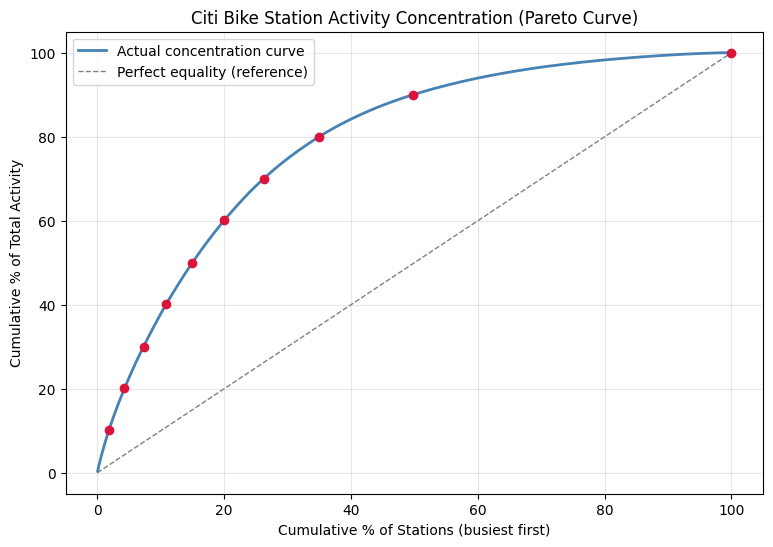

In [47]:
# Cell 34.12 - Plot Concentration Curve
# ============================================================
# Purpose:
## Draws the concentration curve as a static image using
# matplotlib: the actual busiest-first activity curve, a
# dashed gray reference diagonal showing what perfectly even
# distribution would look like, and red dots marking each of
# the 10 decile crossing points computed in Cell 34.11.
#
# Why?
## matplotlib produces a fixed, non-interactive image - useful
# for a quick visual check or for embedding in a static
# report, but it cannot show exact values on hover. See Cell
# 34.13 for an interactive version of the same chart.
# ============================================================
# Purpose:
# Rebuilds the same chart as Cell 34.12, but with plotly
# instead of matplotlib, so each point on the curve and each
# decile marker can be hovered over to show its exact station
# count and activity share, rather than only being readable
# from the static image.
#
# Why?
# plotly renders an interactive figure rather than a fixed
# image. pio.renderers.default is set explicitly to "colab" -
# without this, fig.show() can silently produce no visible
# output in some Colab sessions.
# ===========================================================$0

plt.figure(figsize=(9, 6))
plt.plot(
    station_activity['cumulative_pct_stations'],
    station_activity['cumulative_pct_activity'],
    color='steelblue', linewidth=2, label='Actual concentration curve'
)
plt.plot([0, 100], [0, 100], color='gray', linestyle='--',
         linewidth=1, label='Perfect equality (reference)')
plt.scatter(
    concentration_summary['pct_of_all_stations'],
    concentration_summary['actual_pct_achieved'],
    color='crimson', zorder=5
)
plt.xlabel('Cumulative % of Stations (busiest first)')
plt.ylabel('Cumulative % of Total Activity')
plt.title('Citi Bike Station Activity Concentration (Pareto Curve)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [48]:
# ============================================================
# Cell 34.13 - Plot Concentration Curve (Interactive)
# ============================================================
# Purpose:
#
# Rebuilds the same chart as Cell 34.12, but with plotly
# instead of matplotlib, so each point on the curve and each
# decile marker can be hovered over to show its exact station
# count and activity share, rather than only being readable
# from the static image.
#
# Why?
#
# plotly renders an interactive figure rather than a fixed
# image. pio.renderers.default is set explicitly to "colab" -
# without this, fig.show() can silently produce no visible
# output in some Colab sessions.
# ============================================================
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "colab"

fig = go.Figure()

# Actual concentration curve
# line, with hover text showing the exact station/activity %
# at any point along it

fig.add_trace(go.Scatter(
    x=station_activity['cumulative_pct_stations'],
    y=station_activity['cumulative_pct_activity'],
    mode='lines',
    name='Actual concentration curve',
    line=dict(color='steelblue', width=2),
    hovertemplate='Stations: %{x:.2f}%<br>Activity: %{y:.2f}%<extra></extra>'
))

# Reference diagonal (perfect equality)
fig.add_trace(go.Scatter(
    x=[0, 100], y=[0, 100],
    mode='lines', name='Perfect equality',
    line=dict(color='gray', dash='dash')
))

# Decile markers with full detail on hover
fig.add_trace(go.Scatter(
    x=concentration_summary['pct_of_all_stations'],
    y=concentration_summary['actual_pct_achieved'],
    mode='markers+text',        # markers+text also prints a small label next to each dot
    name='Decile markers',
    marker=dict(color='crimson', size=10),
    text=concentration_summary['target_pct_activity'],   # shows "10%", "20%"... next to each dot
    textposition='top center',
    customdata=concentration_summary[['stations_needed', 'cumulative_activity_units']],
    hovertemplate=(
        'Target: %{text}<br>'
        'Stations needed: %{customdata[0]}<br>'
        'Rides captured: %{customdata[1]:,}<br>'
        '<extra></extra>'
    )
))

fig.update_layout(
    title='Citi Bike Station Activity Concentration (Pareto Curve)',
    xaxis_title='Cumulative % of Stations (busiest first)',
    yaxis_title='Cumulative % of Total Activity',
    xaxis=dict(range=[0, 100]),
    yaxis=dict(range=[0, 100])
)
fig.show()
# Quick sanity check: confirm the underlying data feeding the
# chart looks correct before trusting the visual
print(station_activity[['cumulative_pct_stations', 'cumulative_pct_activity']].head())
print(concentration_summary.head())

   cumulative_pct_stations  cumulative_pct_activity
0                 0.045537                 0.349264
1                 0.091075                 0.696693
2                 0.136612                 1.013713
3                 0.182149                 1.330252
4                 0.227687                 1.615946
  target_pct_activity  stations_needed  pct_of_all_stations  \
0                 10%               40                 1.82   
1                 20%               94                 4.28   
2                 30%              160                 7.29   
3                 40%              238                10.84   
4                 50%              329                14.98   

   cumulative_activity_units  actual_pct_achieved  
0                     231731                10.12  
1                     459521                20.08  
2                     687599                30.04  
3                     917370                40.08  
4                    1144765                50.02

In [49]:
# ============================================================
# Cell 34.14 - Rebuild sorted_df for Verification Checks
# ============================================================
# Purpose:
#
# Recreates a standalone sorted_df from station_activity, in
# case the Colab session was restarted and station_activity is
# the only DataFrame still available in memory. sorted_df is a
# lightweight, busiest-first copy used for one-off verification
# checks (e.g. comparing against the Tableau build, or
# measuring station-to-station variance) without needing to
# re-run the full concentration_summary pipeline in Cell 34.11.
#
# Why?
#
# station_activity may already be sorted from Cell 33, but that
# sort is not guaranteed to survive every operation run on it
# later in the notebook. This cell re-sorts explicitly, busiest
# station first, and rebuilds only the two columns needed for a
# quick check: the running activity total and its cumulative
# percentage of the network total.
# ============================================================

# Sort busiest-first and reset the index so row position
# doubles as rank order (row 0 = busiest station)
sorted_df = station_activity.sort_values('total_activity', ascending=False).reset_index(drop=True)

# Running total of activity as you move down the sorted list
sorted_df['cumulative_activity'] = sorted_df['total_activity'].cumsum()

# Cumulative activity expressed as % of this DataFrame's own
# total (should match Cell 34.11's network_total_activity-based
# percentages as long as no stations are excluded from sorted_df)
sorted_df['cumulative_pct_activity'] = sorted_df['cumulative_activity'] / sorted_df['total_activity'].sum() * 100

# Sanity check: row count should match station_activity's total
# station count (2,196), confirming no rows were lost in the sort
print(f"Rows: {len(sorted_df)}")
sorted_df.head()

Rows: 2196


,level_0,station_name,station_id,latitude,longitude,departures,arrivals,total_activity,station_rank,cumulative_activity,cumulative_pct_activity,cumulative_pct_stations
0,0,W 21 St & 6 Ave,6140.05,40.741740,-73.994156,4007.0,3987,7994.0,1,7994.0,0.349264,0.045537
1,1,Pier 61 at Chelsea Piers,6233.04,40.746872,-74.008210,3930.0,4022,7952.0,2,15946.0,0.696693,0.091075
2,2,Lafayette St & E 8 St,5788.13,40.730207,-73.991026,3667.0,3589,7256.0,3,23202.0,1.013713,0.136612
3,3,West St & Chambers St,5329.03,40.717548,-74.013221,3642.0,3603,7245.0,4,30447.0,1.330252,0.182149
4,4,W 31 St & 7 Ave,6331.01,40.749156,-73.991600,3251.0,3288,6539.0,5,36986.0,1.615946,0.227687


In [50]:
# ============================================================
# Cell 34.15 - Check Available DataFrames in Memory
# ============================================================
# Purpose:
# Lists every DataFrame currently loaded in this Colab
# session, with its variable name, row/column count, and a
# truncated preview of its contents.
#
# Why?
# Run this before Cell 34.14 (or any cell referencing
# sorted_df, station_activity, or similar) if a NameError
# suggests a variable no longer exists - this confirms which
# DataFrames actually survived a session restart, so the right
# one can be rebuilt from source rather than guessed at.
# ============================================================
%whos DataFrame

Variable                Type         Data/Info
----------------------------------------------
arrivals                DataFrame                             <...>\n[2196 rows x 3 columns]
concentration_summary   DataFrame      target_pct_activity  st<...>14               100.00  
departures              DataFrame                             <...>\n[2171 rows x 4 columns]
df                      DataFrame                       ride_i<...>444071 rows x 19 columns]
df_check                DataFrame                ride_id  ride<...>\n4        True  Winter  
df_sample               DataFrame                      ride_id<...>144407 rows x 21 columns]
df_tableau              DataFrame                          sta<...>144407 rows x 20 columns]
duration_summary        DataFrame                    count    <...>672  11.287855   8.320858
end_id                  DataFrame                     arrivals<...>\n[2286 rows x 1 columns]
end_name                DataFrame                             <...>\n

In [51]:
diffs = sorted_df['cumulative_pct_activity'].diff().dropna()

print("Smallest jump between consecutive stations:", diffs.min())
print("Largest jump between consecutive stations:", diffs.max())
print("Average jump:", diffs.mean())
print("Standard deviation of jumps:", diffs.std())

irregular = (diffs - diffs.mean()).abs() > (0.5 * diffs.mean())
print(f"Stations with an unusually large or small jump: {irregular.sum()} out of {len(diffs)}")

Smallest jump between consecutive stations: 4.369074986243504e-05
Largest jump between consecutive stations: 0.347428843060205
Average jump: 0.04539896863118212
Standard deviation of jumps: 0.05364833213743976
Stations with an unusually large or small jump: 1662 out of 2195


In [52]:
# ============================================================
# Cell # 35
# ============================================================
# Export Tableau Datasets
## Purpose:
## Save the final Tableau-ready datasets to
# Google Drive.
#
# These files will be imported into Tableau
# Public for dashboard development.
## ============================================================
#
# Files Created:
## 1. citibike_tableau_clean.csv
##    Trip-level Tableau dataset
## 2. citibike_station_activity_by_name.csv
##    Station-level summary dataset
##    One Row = One Station
##    Business Key = Station Name
#
# ============================================================

trip_output_file = (
    '/content/drive/MyDrive/CitibikeDataSets/'
    'citibike_tableau_clean.csv'
)

station_output_file = (
    '/content/drive/MyDrive/CitibikeDataSets/'
    'citibike_station_activity_by_name.csv'
)

df_tableau.to_csv(
    trip_output_file,
    index=False
)

station_activity.to_csv(
    station_output_file,
    index=False
)

print("Files Created Successfully")
print("--------------------------")
print(trip_output_file)
print(station_output_file)

Files Created Successfully
--------------------------
/content/drive/MyDrive/CitibikeDataSets/citibike_tableau_clean.csv
/content/drive/MyDrive/CitibikeDataSets/citibike_station_activity_by_name.csv


In [53]:
# ============================================================
# Cell # 36 Tableau Dashboard Plan
# ============================================================
# Dashboard 1
# Project Overview & Story Framework
# Project Goal
#
# Dashboard 2
# Network Overview
# Where does Citi Bike activity occur across New York City's bike-sharing network, and which stations generate the highest and lowest levels of demand?
#
# Dashboard 3
# Rider Behaviour Analysis
# Who uses Citi Bike, how does ridership change across seasons, and how do riding patterns differ between Members and Casual riders?
#
# Dashboard 4
# Bike Usage Patterns
# What bicycle types do riders prefer across rider groups, seasons, and usage patterns?
#
# Dashboard 5
# # Final Conclusions
# Key Findings, Final Takeaw

In [54]:
# ============================================================
# Cell # 37
# ============================================================
# Recommendations for Tableau Storytelling
# ============================================================
# Investigation showed:
#
# - Seasonal patterns were preserved after sampling.
#
# - Station names and station IDs produced nearly
#   identical station popularity rankings.
#
# - Station names were selected as the business
#   dimension because they are more user friendly.
#
# - Total Activity was selected as the station
#   popularity metric because it combines both
#   departures and arrivals.
#
# These findings will guide dashboard development
# and business recommendations.
#
# ============================================================

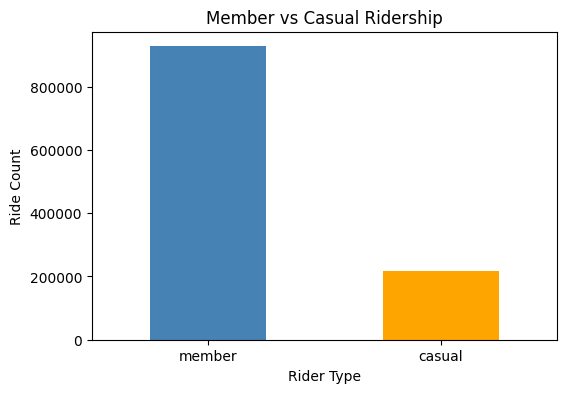

In [55]:
"""
============================================================
Cell 38 - Member vs Casual Ridership
------------------------------------------------------------
Purpose:
Visualize the distribution of rides between Member and
Casual riders.

Understanding rider composition helps answer the
business question:
    Who uses Citi Bike and how?

Expected Result:
Member riders should account for the majority of rides,
indicating that Citi Bike is used primarily by
frequent riders and commuters.

This visualization supports the Rider Behavior
Analysis section of the project.
============================================================
"""
member_counts = (
    df_tableau['member_casual']
    .value_counts()
)

plt.figure(figsize=(6,4))
member_counts.plot(
    kind='bar',
    color=['steelblue', 'orange']
)

plt.title('Member vs Casual Ridership')
plt.ylabel('Ride Count')
plt.xlabel('Rider Type')
plt.xticks(rotation=0)

plt.show()

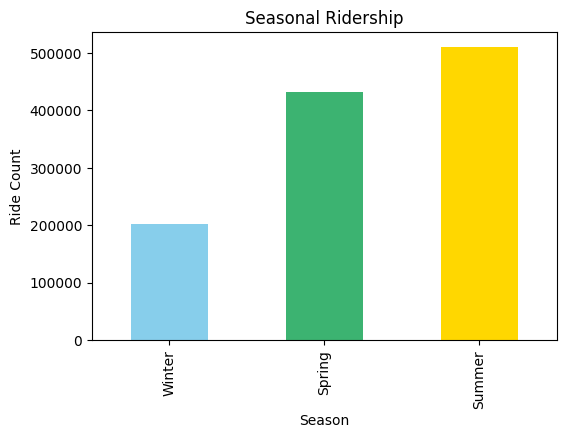

In [56]:
"""
============================================================
Cell 39 - Seasonal Ridership
------------------------------------------------------------
Purpose:
Compare total ridership across Winter, Spring,
and Summer.

Seasonality is an important factor in bike-sharing
systems because weather conditions strongly influence
ridership demand.

Expected Result:
Summer should show the highest ridership,
followed by Spring and then Winter.

This visualization validates that the 10% stratified
sample preserved the original seasonal patterns.
============================================================
"""
season_counts = (
    df_tableau['season']
    .value_counts()
    .reindex(['Winter','Spring','Summer'])
)

plt.figure(figsize=(6,4))

season_counts.plot(
    kind='bar',
    color=['skyblue','mediumseagreen','gold']
)

plt.title('Seasonal Ridership')
plt.ylabel('Ride Count')
plt.xlabel('Season')

plt.show()

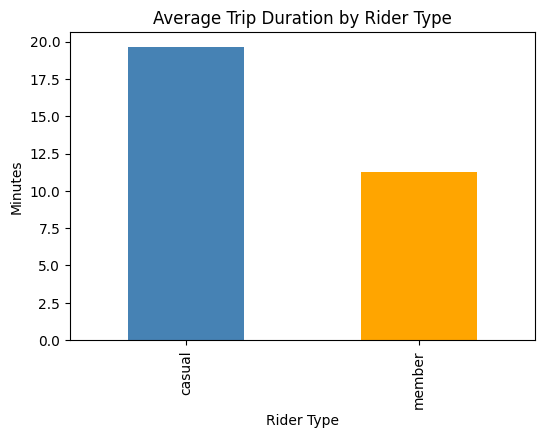

In [57]:
"""
============================================================
Cell 40 - Average Trip Duration by Rider Type
------------------------------------------------------------
Purpose:
Compare average trip duration between Member
and Casual riders.

Trip duration provides insight into rider behavior.

Expected Result:
Casual riders are expected to have longer average
trip durations than Members.

This may suggest that Members primarily use Citi Bike
for transportation and commuting, while Casual riders
use Citi Bike more often for leisure and recreation.
============================================================
"""

duration_summary['mean'].plot(
    kind='bar',
    color=['steelblue','orange'],
    figsize=(6,4)
)

plt.title('Average Trip Duration by Rider Type')
plt.ylabel('Minutes')
plt.xlabel('Rider Type')

plt.show()

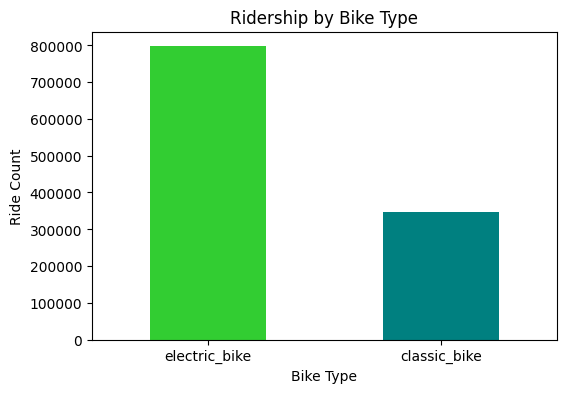

In [58]:
"""
============================================================
Cell 41 - Bike Type Preference
------------------------------------------------------------
Purpose:
Analyze rider preference between Classic and
Electric bicycles.

Bike type selection provides insight into rider
demand and system usage patterns.

Expected Result:
Electric bicycles should account for the majority
of rides.

This visualization supports the business question:
    What bicycle types do riders prefer?

and helps identify demand trends within the Citi
Bike network.
============================================================
"""

bike_counts = (
    df_tableau['rideable_type']
    .value_counts()
)

plt.figure(figsize=(6,4))

bike_counts.plot(
    kind='bar',
    color=['limegreen','teal']
)

plt.title('Ridership by Bike Type')
plt.ylabel('Ride Count')
plt.xlabel('Bike Type')
plt.xticks(rotation=0)

plt.show()

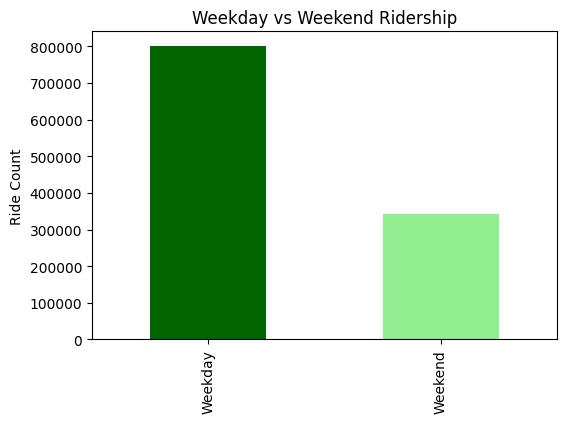

In [59]:
"""
============================================================
Cell 42 - Weekday vs Weekend Ridership
------------------------------------------------------------
Purpose:
Compare ridership volume between weekdays and
weekends.

Understanding when Citi Bike is used helps identify
whether the system functions primarily as a commuter
transportation network, a recreational service, or a
combination of both.

Weekday ridership is often associated with work and
school commuting, while weekend ridership may reflect
recreation, leisure, and sightseeing activities.

Expected Result:
Weekdays are expected to generate more rides than
weekends due to regular commuting patterns.

A substantial level of weekend ridership would suggest
that Citi Bike also serves recreational and leisure
purposes throughout New York City.
This visualization supports the business question:
    Who uses Citi Bike and how?
and helps explain rider behavior across different
usage patterns.
============================================================
"""

weekend_counts = (
    df_tableau['is_weekend']
    .value_counts()
)

weekend_counts.index = ['Weekday', 'Weekend']

plt.figure(figsize=(6,4))

weekend_counts.plot(
    kind='bar',
    color=['darkgreen','lightgreen']
)

plt.title('Weekday vs Weekend Ridership')
plt.ylabel('Ride Count')

plt.show()

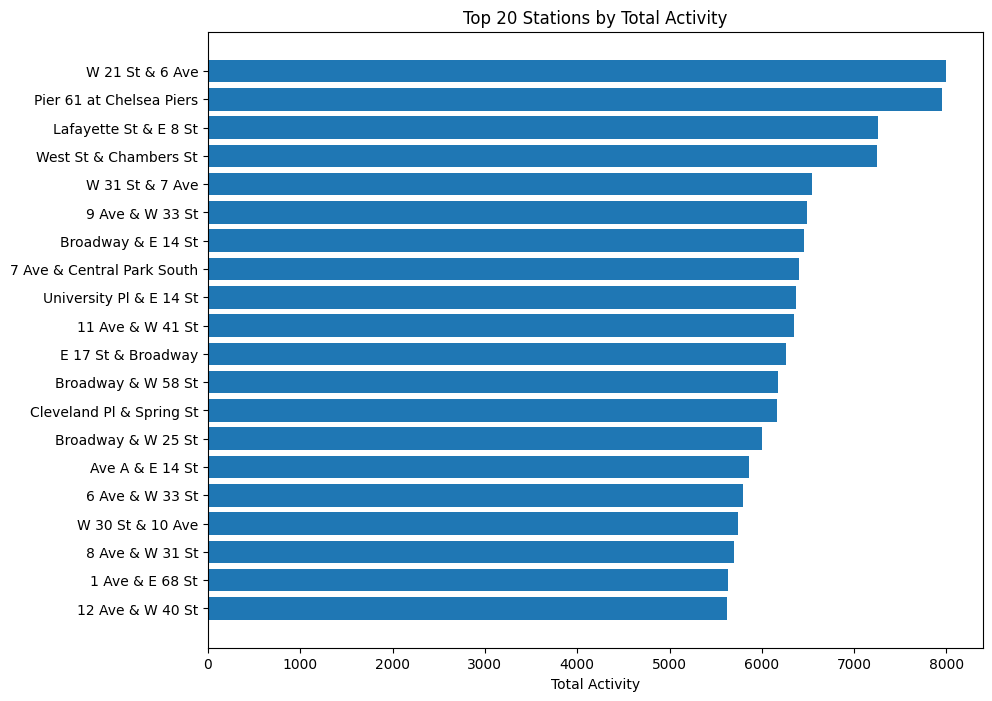

In [60]:
"""
============================================================
Cell 43 - Top 20 Stations by Total Activity
------------------------------------------------------------
Purpose:
Identify the busiest stations in the Citi Bike
networks

Station activity is measured using:
    Total Activity =
    Departures + Arrivals

This metric captures overall station utilization.
Expected Result:

A relatively small number of stations should account
for a large portion of total network activity.

This visualization helps answer the business
question:
    Where does Citi Bike activity occur?

and supports station demand analysis and capacity
planning recommendations.
============================================================
"""

top20 = (
    station_activity
    .head(20)
    .sort_values('total_activity')
)

plt.figure(figsize=(10,8))

plt.barh(
    top20['start_station_name']
    if 'start_station_name' in top20.columns
    else top20['station_name'],
    top20['total_activity']
)

plt.title('Top 20 Stations by Total Activity')
plt.xlabel('Total Activity')

plt.show()

Median Weekday        13660.5
Median Weekend Day    14958.0
Name: ride_count, dtype: float64


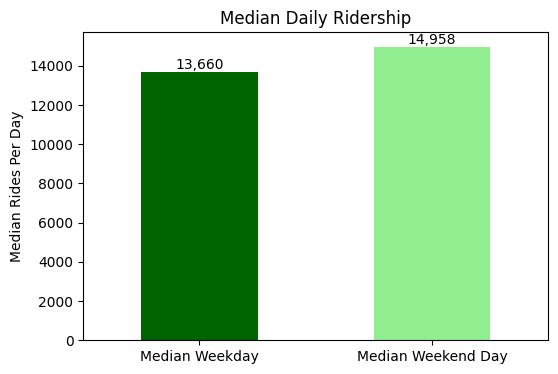

In [61]:
"""
============================================================
Cell 44 - Median Daily Ridership
------------------------------------------------------------
Purpose:
Compare the median number of rides occurring on a
typical weekday versus a typical weekend day.

Mean averages can be influenced by unusually busy
or unusually slow days.

The median represents the middle daily ridership
value and provides a more typical representation of
daily usage patterns.

Expected Result:
If the median weekend ridership exceeds the median
weekday ridership, this suggests that a typical
weekend day generates more riding activity despite
there being fewer weekend days overall.

This analysis helps evaluate whether Citi Bike is
used primarily for commuting or whether recreational
and leisure riding also contribute significantly to
system demand.
============================================================
"""

# Daily ride counts
daily_counts = (
    df_tableau
    .groupby(['trip_date', 'is_weekend'])
    .size()
    .reset_index(name='ride_count')
)

# Median rides per day

median_daily = (
    daily_counts
    .groupby('is_weekend')['ride_count']
    .median()
)

median_daily.index = ['Median Weekday', 'Median Weekend Day']

print(median_daily)

ax = median_daily.plot(
    kind='bar',
    figsize=(6, 4),
    color=['darkgreen', 'lightgreen']
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():,.0f}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Median Daily Ridership')
plt.ylabel('Median Rides Per Day')
plt.xlabel('')
plt.xticks(rotation=0)

plt.show()

weekday = median_daily.iloc[0]
weekend = median_daily.iloc[1]



In [ ]:
# ============================================================
# Dataset Overview
# ============================================================
#
# Three datasets were used throughout the project:
#
# 1. citibike_clean.csv
#    Purpose:
#       Master cleaned Citi Bike dataset used as the
#       primary source for analysis and data preparation.
#
#    Size:
#       - 11,444,071 rides
#       - 19 columns
#       - Approximately 2.52 GB
#
#    Key Fields:
#       - started_at
#       - ended_at
#       - duration_min
#       - member_casual
#       - rideable_type
#       - start/end station IDs
#       - start/end station names
#       - start/end coordinates
#       - month, season, day_of_week
#       - hour, is_weekend
#
#    Use:
#       Source dataset for cleaning, validation,
#       feature engineering, sampling, and creation
#       of downstream analytical datasets.
#
# ------------------------------------------------------------
#
# 2. citibike_tableau_clean.csv
#    Purpose:
#       Tableau-ready trip-level dataset created from a
#       10% stratified seasonal sample of the master dataset.
#
#    Size:
#       - Approximately 1.14 million rides
#       - One row per trip
#       - Roughly 10% of the original dataset
#
#    Key Fields:
#       - started_at
#       - ended_at
#       - trip_date
#       - year_month
#       - duration_min
#       - member_casual
#       - rideable_type
#       - season
#       - day_of_week
#       - hour
#       - is_weekend
#       - station IDs, names, and coordinates
#
#    Use:
#       Tableau dashboards, seasonal analysis,
#       ridership trends, Member vs Casual analysis,
#       bike type analysis, and visualization.
#
# ------------------------------------------------------------
#
# 3. citibike_station_activity_by_name.csv
#    Purpose:
#       Station-level aggregated dataset used to measure
#       station popularity and overall network activity.
#
#    Size:
#       - Approximately 2,196 stations
#       - One row per station
#
#    Key Fields:
#       - station_name
#       - station_id
#       - latitude
#       - longitude
#       - departures
#       - arrivals
#       - total_activity
#
#    Use:
#       Station rankings, station activity maps,
#       popularity analysis, Pareto analysis,
#       busiest station identification, and
#       network concentration studies.
#
# ============================================================